# 01 · Data Pipeline — Quick Test & Validation
**Script chính:** `scripts/run_data_pipeline.py`  
**Notebook này:** Load kết quả đã chạy → kiểm tra shape, NaN, phân phối, data quality.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.utils.io import load

cfg = load_config(ROOT / 'configs' / 'base.yaml')
print(f"Config: {len(cfg.data.tickers)} tickers | {cfg.data.start_date} → {cfg.data.end_date}")

Config: 72 tickers | 2016-01-01 → 2026-03-01


## 1. Load & Validate dataset.parquet

In [2]:
df = load(cfg.dir_processed / 'dataset.parquet')

n_tickers = df.index.get_level_values('ticker').nunique()
n_dates = df.index.get_level_values('date').nunique()
expected_cols = {'adj_open', 'adj_high', 'adj_low', 'adj_close', 'adj_volume',
                 'vix', 'vxn', 'bench_close', 'treasury_10y', 'treasury_2y'}

print(f"Shape: {df.shape}")
print(f"Tickers: {n_tickers} | Dates: {n_dates}")
print(f"Columns: {sorted(df.columns.tolist())}")
print(f"\n--- Checks ---")
assert df.index.names == ['date', 'ticker'], "Index phải là [date, ticker]"
assert expected_cols.issubset(df.columns), f"Thiếu cột: {expected_cols - set(df.columns)}"
assert n_tickers >= 60, f"Quá ít tickers: {n_tickers}"
assert n_dates >= 2000, f"Quá ít dates: {n_dates}"
assert (df['adj_close'].dropna() > 0).all(), "adj_close phải > 0"
assert (df['adj_volume'].dropna() >= 0).all(), "adj_volume phải >= 0"
print("OK: Index, columns, value constraints")

Shape: (173604, 10)
Tickers: 68 | Dates: 2553
Columns: ['adj_close', 'adj_high', 'adj_low', 'adj_open', 'adj_volume', 'bench_close', 'treasury_10y', 'treasury_2y', 'vix', 'vxn']

--- Checks ---
OK: Index, columns, value constraints


## 1b. Data Inspection — nhìn thẳng vào dữ liệu

Trước khi chạy assertion + plot tổng hợp, in trực tiếp `head/tail`, `describe`, `dtypes`, sample 1 ticker để xác nhận luồng dữ liệu đúng như kỳ vọng.

In [3]:
print("--- df.head(10) ---")
print(df.head(10).round(4).to_string())

print("\n--- df.tail(5) ---")
print(df.tail(5).round(4).to_string())

print("\n--- df.dtypes ---")
print(df.dtypes.to_string())

print(f"\n--- Memory: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB ---")

print("\n--- df.describe() ---")
print(df.describe().round(4).to_string())

print("\n--- Sample: AAPL last 10 trading days ---")
aapl = df.xs('AAPL', level='ticker').tail(10)
print(aapl.round(4).to_string())

print("\n--- Date range per ticker (first 10 tickers) ---")
date_range = df.reset_index().groupby('ticker').agg(
    first_date=('date', 'min'),
    last_date=('date', 'max'),
    n_rows=('date', 'count'),
)
print(date_range.head(10).to_string())

--- df.head(10) ---
                   adj_open  adj_high   adj_low  adj_close   adj_volume   vix    vxn  bench_close  treasury_10y  treasury_2y
date       ticker                                                                                                           
2016-01-04 AAPL     23.1130   23.7342   22.9756    23.7302  270597548.0  20.7  22.42     101.7173          2.24         1.02
           ADBE     91.7700   92.0000   90.5400    91.9700    2993832.0  20.7  22.42     101.7173          2.24         1.02
           ADI      44.3482   44.5362   43.8494    44.5117    2648908.0  20.7  22.42     101.7173          2.24         1.02
           ADP      66.2660   66.4738   64.9236    65.5788    2246327.0  20.7  22.42     101.7173          2.24         1.02
           AMAT     16.2833   16.4256   16.1900    16.4256   13331704.0  20.7  22.42     101.7173          2.24         1.02
           AMD       2.7700    2.8200    2.6300     2.7700   32516771.0  20.7  22.42     101.7173        

## 2. NaN Report

In [4]:
nan_pct = df.isna().mean().sort_values(ascending=False) * 100
print("NaN % per column:")
print(nan_pct.to_string())
print(f"\nOverall NaN: {df.isna().mean().mean():.2%}")
assert df.isna().mean().mean() < 0.05, "NaN rate quá cao (>5%)"
print("OK: NaN rate acceptable")

NaN % per column:
adj_open        0.001728
adj_high        0.001728
adj_low         0.001728
adj_close       0.001728
adj_volume      0.001728
vix             0.000000
vxn             0.000000
bench_close     0.000000
treasury_10y    0.000000
treasury_2y     0.000000

Overall NaN: 0.00%
OK: NaN rate acceptable


## 3. QC Report — Tickers bị loại

In [5]:
qc = load(cfg.dir_outputs / 'metrics' / 'qc_report.parquet')
qc_fail = qc[~qc['valid']]
qc_pass = qc[qc['valid']]

print(f"Pass: {len(qc_pass)} | Fail: {len(qc_fail)}")
if len(qc_fail):
    print(f"\nFailed tickers:")
    print(qc_fail[['ticker', 'n_valid', 'nan_pct_max_col', 'max_consec', 'valid']].to_string(index=False))

assert len(qc_pass) == n_tickers, "QC pass count != dataset ticker count"
print(f"\nOK: {len(qc_pass)} tickers pass QC = {n_tickers} tickers in dataset")

Pass: 68 | Fail: 4

Failed tickers:
ticker  n_valid  nan_pct_max_col  max_consec  valid
  ABNB     1309            48.73        1244  False
  ANSS     2412             5.52         140  False
  MRNA     1815            28.91         738  False
  RIVN     1078            57.78        1475  False

OK: 68 tickers pass QC = 68 tickers in dataset


ticker  n_valid  nan_pct_max_col  max_consec  valid
  ABNB     1309            48.73        1244  False
  ANSS     2412             5.52         140  False
  MRNA     1815            28.91         738  False
  RIVN     1078            57.78        1475  False

OK: 68 tickers pass QC = 68 tickers in dataset


## 4. Visualize — Price distribution & Coverage

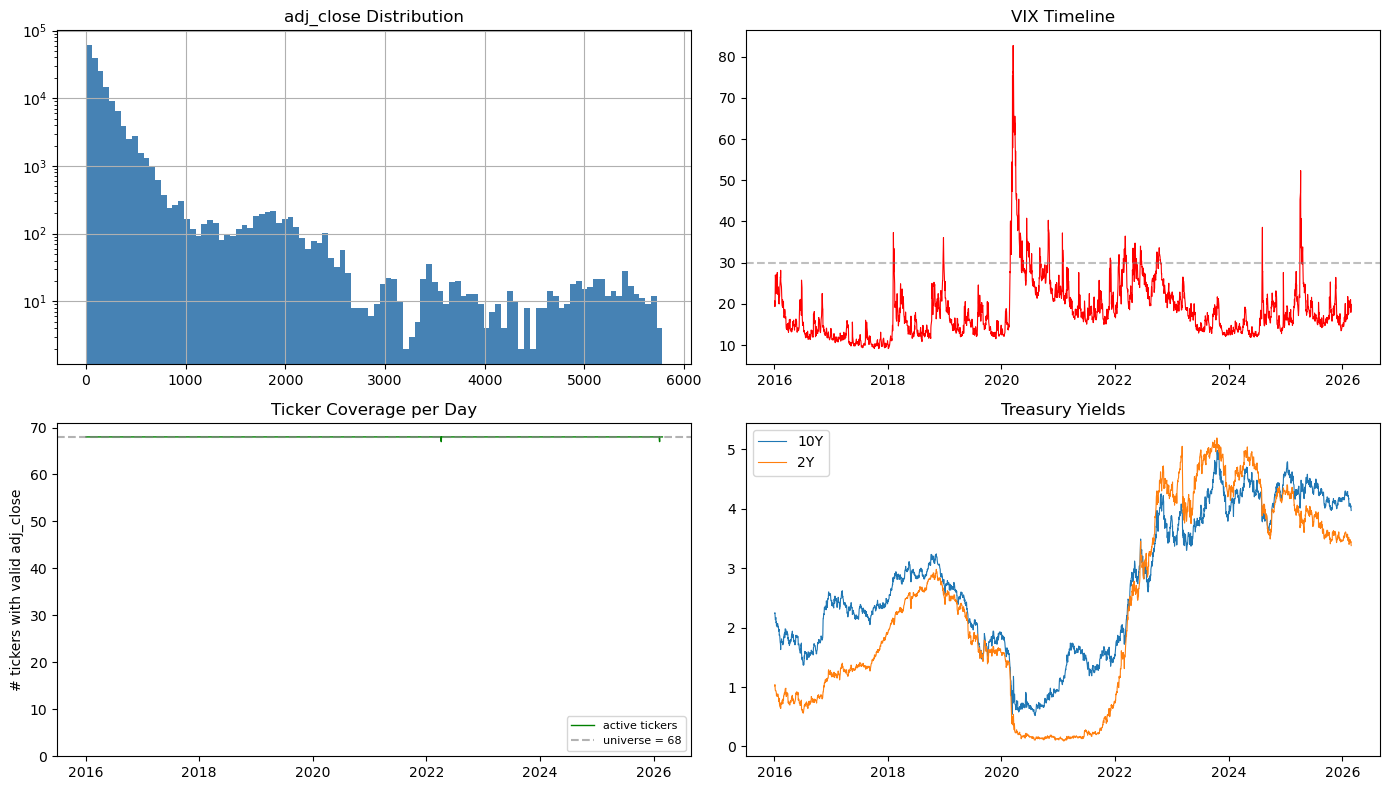

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) adj_close distribution (log scale)
df['adj_close'].dropna().hist(bins=100, ax=axes[0, 0], color='steelblue', edgecolor='none')
axes[0, 0].set_title('adj_close Distribution')
axes[0, 0].set_yscale('log')

# (b) VIX timeline
vix = df.groupby(level='date')['vix'].first()
axes[0, 1].plot(vix.index, vix.values, linewidth=0.8, color='red')
axes[0, 1].set_title('VIX Timeline')
axes[0, 1].axhline(30, ls='--', color='gray', alpha=0.5)

# (c) Ticker coverage over time — count tickers with a valid adj_close per day.
# Dataset is reindexed to a complete (date x ticker) grid, so grouping by date
# alone always equals the universe size; the non-null count surfaces the
# step-up as post-2016 IPOs (ABNB, DASH, RIVN...) enter the universe.
coverage = df['adj_close'].dropna().groupby(level='date').size()
axes[1, 0].plot(coverage.index, coverage.values, linewidth=1.0, color='green',
                label='active tickers')
axes[1, 0].axhline(n_tickers, ls='--', color='gray', alpha=0.6,
                   label=f'universe = {n_tickers}')
axes[1, 0].set_title('Ticker Coverage per Day')
axes[1, 0].set_ylabel('# tickers with valid adj_close')
axes[1, 0].set_ylim(0, n_tickers + 3)
axes[1, 0].legend(loc='lower right', fontsize=8)

# (d) Treasury yields
if 'treasury_10y' in df.columns:
    t10 = df.groupby(level='date')['treasury_10y'].first()
    t2 = df.groupby(level='date')['treasury_2y'].first()
    axes[1, 1].plot(t10.index, t10.values, label='10Y', linewidth=0.8)
    axes[1, 1].plot(t2.index, t2.values, label='2Y', linewidth=0.8)
    axes[1, 1].set_title('Treasury Yields')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5. Pandera Schema Validation

In [7]:
from src.data.schemas import validate_dataset

try:
    validate_dataset(df)
    print("OK: Pandera DatasetSchema validation passed")
except Exception as e:
    print(f"FAIL: {e}")

OK: Pandera DatasetSchema validation passed


In [8]:
print("=" * 50)
print("01_data_etl: ALL CHECKS PASSED")
print(f"  Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Universe: {n_tickers} tickers, {n_dates} dates")
print(f"  NaN rate: {df.isna().mean().mean():.2%}")
print("=" * 50)

01_data_etl: ALL CHECKS PASSED
  Dataset: 173,604 rows x 10 cols
  Universe: 68 tickers, 2553 dates
  NaN rate: 0.00%
